In [1]:
from pathlib import Path
from itertools import product
from glob import glob

import cartopy.crs as ccrs
import iris
from IPython.display import HTML, clear_output
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import FuncFormatter
from matplotlib.animation import FuncAnimation
import matplotlib.colors as mcolors
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.ndimage as ndimage
import scipy.stats
import seaborn as sns
import xarray as xr
import xesmf as xe

from mcs_prime import mcs_prime_config_util as cu

In [2]:
imerg_path = '/gws/nopw/j04/mcs_prime/mmuetz/data/mcs_prime_output/imerg_processed/N216grid/2020-07-01_04:00:00-2020-07-11_03:00:00/3B-HHR.MS.MRG.3IMERG.2020-07-01_04:00:00-2020-07-11_03:00:00.hourly.V07B.nc'
imerg = xr.load_dataarray(imerg_path)

In [10]:
imerg

<xarray.DataArray (time: 240, latitude: 324, longitude: 432)>
array([[[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        ...,
        [0.11      , 0.14056149, 0.14056125, ..., 0.        ,
         0.        , 0.        ],
        [0.0999866 , 0.13666438, 0.11833221, ..., 0.19999999,
         0.19999999, 0.19999999],
        [0.10113055, 0.14889447, 0.07223611, ..., 0.13      ,
         0.03609293, 0.13      ]],

       [[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
...
        [0.18146932, 0.3516631 , 0.35166326, ..., 0.18424271,
         0.16      , 0.29999998],
        [0.34666443, 0.36666438, 0.36166778, ..., 0.32500336,
         0.32833904, 0.3316745 ],
        [0.5055861 , 0.6128267 ,        nan, ..., 0.37555498,
         0.39888787, 0.43574366]],

       [[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        ...,
        [0.34      , 0.3477754 , 0.34      , ..., 0.3277755 ,
         0.3338877 , 0.34      ],
        [0.2600067 , 0.31333563, 0.31333557, ..., 0.36499664,
         0.31500342, 0.31833893],
        [0.45889443, 0.45889446, 0.21758379, ..., 0.73169583,
         0.64557654, 0.5316856 ]]], dtype=float32)
Coordinates:
  * time       (time) object 2020-07-01 04:00:00 ... 2020-07-11 03:00:00
  * longitude  (longitude) float32 0.4167 1.25 2.083 2.917 ... 357.9 358.7 359.6
  * latitude   (latitude) float32 -89.72 -89.17 -88.61 ... 88.61 89.17 89.72
Attributes:
    regrid_method:        bilinear
    created by:           /home/users/mmuetz/projects/mcs_prime/ctrl/stoch_tr...
    calling file source:  import numpy as np\nimport pandas as pd\nimport xar...
    project repository:   https://github.com/markmuetz/MCS_PRIME
    remake version:       ['0', '7', '0', '0', 'beta']
    remake repository:    https://github.com/markmuetz/remake
    task:                 <N216_sims_process.RegridImergToN216 object at 0x7f...
    task doc:             Regrid IMERG to the same grid as N216 simulations.\...
    created on:           2024-09-03 14:54:15.471534
    nodename:             host639.jc.rl.ac.uk
    hostname:             jasmin
    output path:          /gws/nopw/j04/mcs_prime/mmuetz/data/mcs_prime_outpu...
    contact:              mark.muetzelfeldt@reading.ac.uk

(0.0001, 100.0)

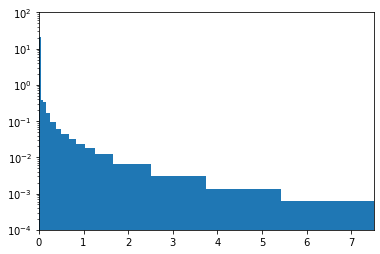

In [3]:
bins_mmpday = np.array([0, 1, 2, 4, 6, 9, 12, 16, 20, 25, 30, 40, 60, 90, 130, 180, 100000])
bins = bins_mmpday / 24
plt.hist(imerg.values.flatten(), bins=bins, log=True, density=True)
plt.xlim((0, 180 / 24))
plt.ylim((1e-4, 1e2))

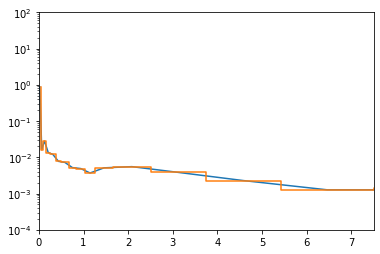

In [4]:
# hist = np.histogram(imerg.values.flatten(), bins=bins, density=True)[0]
hist = np.histogram(imerg.values.flatten(), bins=bins)[0]
# hist = hist / (bins[1:] - bins[:-1])
hist = hist / hist.sum()
plt.plot((bins[:-1] + bins[1:]) / 2, hist)
plt.step(bins[1:], hist)
plt.xlim((0, 180 / 24))
plt.ylim((1e-4, 1e2))
plt.gca().set_yscale('log')

In [5]:
dbins = bins[1:-1]
d = np.digitize(imerg.values, bins=dbins)
d.shape

(240, 324, 432)

In [6]:
probs = np.zeros((len(dbins) + 1, len(dbins) + 1))
for p in zip(d[:-1].flatten(), d[1:].flatten()):
    probs[p] += 1
probs = probs / probs.sum()

Text(0, 0.5, 'probability of precip. in bin')

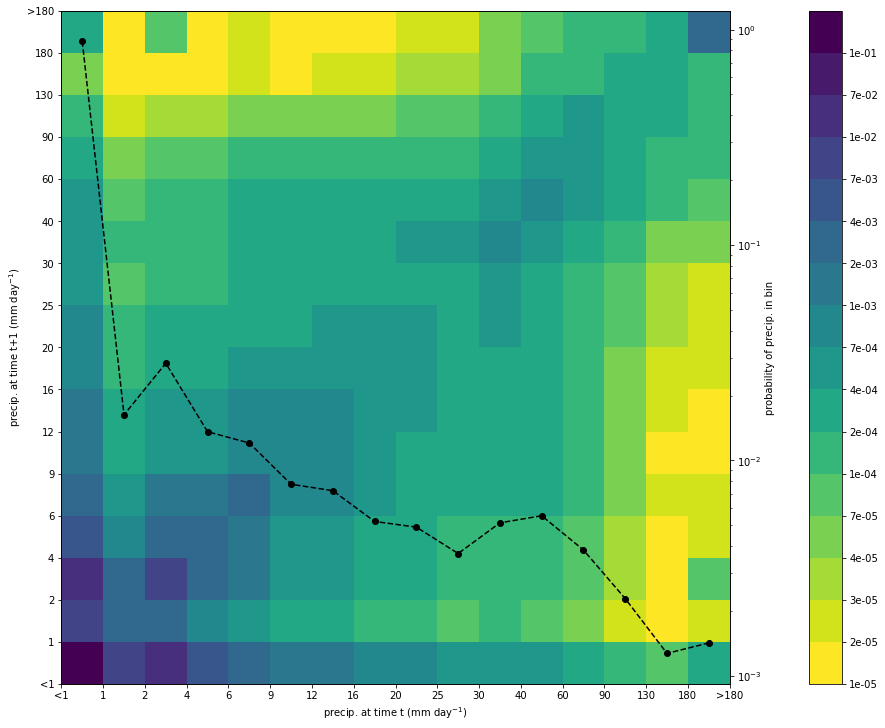

In [7]:
boundaries = [1e-5, 2e-5, 3e-5, 4e-5, 7e-5, 1e-4, 2e-4, 4e-4, 7e-4, 1e-3, 2e-3, 4e-3, 7e-3, 1e-2, 7e-2, 1e-1, 1]

norm = mcolors.BoundaryNorm(boundaries, 256)

# This is bizarly sensitive to the *exact* figsize. Very weird.
fig, ax = plt.subplots(figsize=(12.21, 10), layout='constrained')
ax2 = ax.twinx()
ax2.plot(np.arange(0.5, len(hist) + 0.5), hist, ls='--', marker='o', c='k')
ax2.set_yscale('log')

# im = ax.imshow(probs, origin='lower', norm=norm, cmap='viridis_r')
im = ax.pcolormesh(probs, norm=norm, cmap='viridis_r')

def cbar_fmt_tick(v, pos):
    return f'{v:.0e}'
plt.colorbar(im, ax=ax, ticks=boundaries[:-1], format=FuncFormatter(cbar_fmt_tick), boundaries=np.linspace(0, 1, len(boundaries) - 1))

dbins_mmpday = bins_mmpday[1:-1]
ticks = np.arange(len(dbins) + 2)
ticklabels = ['<1'] + [f'{b:.0f}' for b in dbins_mmpday] + ['>180']
ax.set_xticks(ticks, ticklabels)
ax.set_yticks(ticks, ticklabels);
#ax.set_ylim((-0.5, 15.4))
#ax2.set_yticks(boundaries);
#ax2.set_ylim((1e-3, 2e0))
#ax.set_aspect('equal')

ax.set_xlabel('precip. at time t (mm day$^{-1}$)')
ax.set_ylabel('precip. at time t+1 (mm day$^{-1}$)')
ax2.set_ylabel('probability of precip. in bin')

#ax.autoscale(False)
#ax2.autoscale(False)

In [8]:
boundary_ticklabels = [f'{b:.0E}'.replace('E', 'e') for b in boundaries]
print(boundary_ticklabels)


['1e-05', '2e-05', '3e-05', '4e-05', '7e-05', '1e-04', '2e-04', '4e-04', '7e-04', '1e-03', '2e-03', '4e-03', '7e-03', '1e-02', '7e-02', '1e-01', '1e+00']


In [9]:
def asop_precip_prob_matrix(data):
    bins_mmpday = np.array([0, 1, 2, 4, 6, 9, 12, 16, 20, 25, 30, 40, 60, 90, 130, 180, 100000])
    bins = bins_mmpday / 24

    hist = np.histogram(data.flatten(), bins=bins)[0]
    hist = hist / hist.sum()
    
    dbins = bins[1:-1]
    d = np.digitize(data, bins=dbins)
    
    probs = np.zeros((len(dbins) + 1, len(dbins) + 1))
    for p in zip(d[:-1].flatten(), d[1:].flatten()):
        probs[p] += 1
    probs = probs / probs.sum()

    boundaries = [1e-5, 2e-5, 3e-5, 4e-5, 7e-5, 1e-4, 2e-4, 4e-4, 7e-4, 1e-3, 2e-3, 4e-3, 7e-3, 1e-2, 7e-2, 1e-1, 1]
    norm = mcolors.BoundaryNorm(boundaries, 256)
    
    # If using imshow, this is bizarly sensitive to the *exact* figsize. Very weird.
    fig, ax = plt.subplots(figsize=(12, 10), layout='constrained')
    ax2 = ax.twinx()
    ax2.plot(np.arange(0.5, len(hist) + 0.5), hist, ls='--', marker='o', c='k')
    ax2.set_yscale('log')

    im = ax.pcolormesh(probs, norm=norm, cmap='viridis_r')
    # Bad things happen with alignment of ax if you use imshow.
    # im = ax.imshow(probs, origin='lower', norm=norm, cmap='viridis_r')
    
    def cbar_fmt_tick(v, pos):
        return f'{v:.0e}'
    plt.colorbar(im, ax=ax, ticks=boundaries[:-1], format=FuncFormatter(cbar_fmt_tick), boundaries=np.linspace(0, 1, len(boundaries) - 1))
    
    dbins_mmpday = bins_mmpday[1:-1]
    ticks = np.arange(len(dbins) + 2)
    ticklabels = ['<1'] + [f'{b:.0f}' for b in dbins_mmpday] + ['>180']
    ax.set_xticks(ticks, ticklabels)
    ax.set_yticks(ticks, ticklabels);
    
    ax.set_xlabel('precip. at time t (mm day$^{-1}$)')
    ax.set_ylabel('precip. at time t+1 (mm day$^{-1}$)')
    ax2.set_ylabel('probability of precip. in bin')

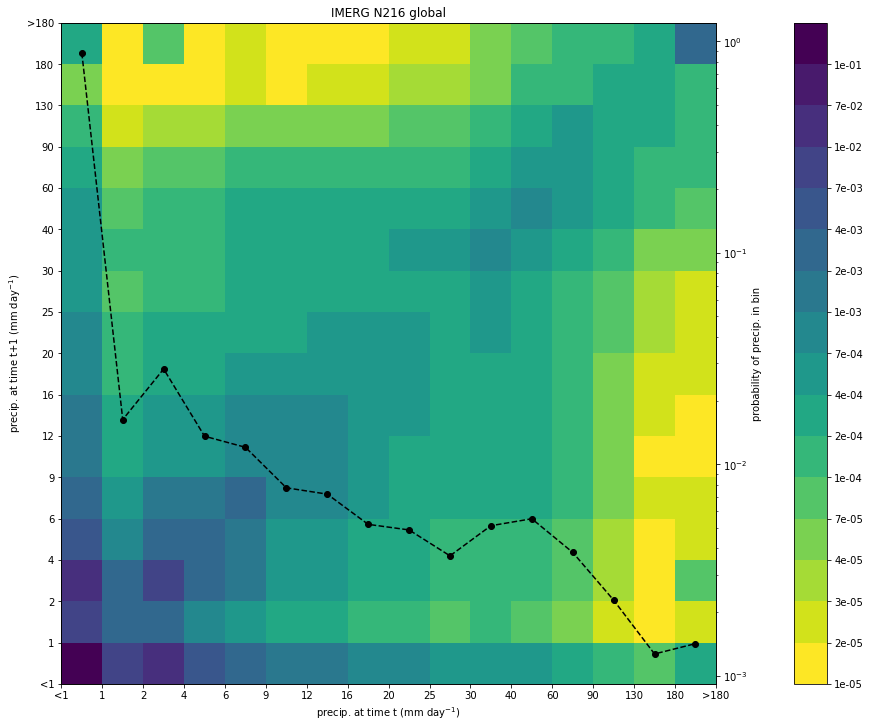

In [10]:
asop_precip_prob_matrix(imerg.values)
plt.title('IMERG N216 global');

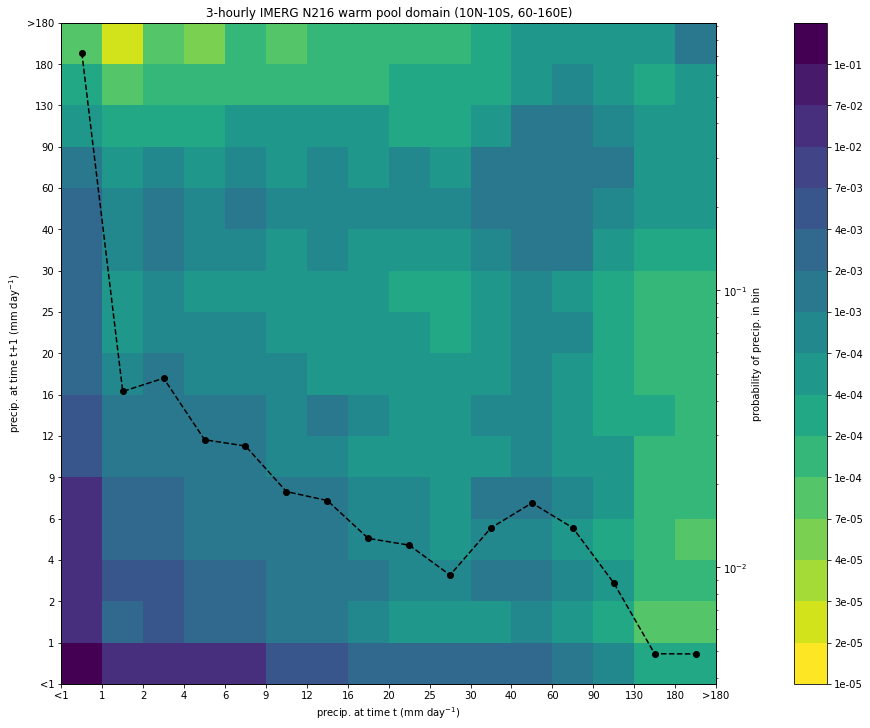

In [11]:
asop_precip_prob_matrix(imerg.coarsen(time=3).mean().sel(longitude=slice(60, 160), latitude=slice(-10, 10)).values)
plt.title('3-hourly IMERG N216 warm pool domain (10N-10S, 60-160E)');

In [43]:
def asop_fractional_contrib(da, time_mean):
    thresh = np.array([0.005, 10, 50, 100]) / 24
    dig_data = np.digitize(da.values, thresh)

    html_colours = ['#2166ac', '#4393c3', '#92c5de', '#d1e5f0', '#f7f7f7', '#fddbc7', '#f4a582', '#d6604d', '#b2182b', '#ec7014', '#fe9929', '#fec44f', '#fee391', '#fff7bc']
    under_colour = '#2166ac'
    over_colour = '#fff7bc'
    
    cmap = mcolors.ListedColormap(html_colours[1:-1])
    cmap.set_under(under_colour)
    cmap.set_over(over_colour)
    norm = mcolors.BoundaryNorm([0.05, 0.1, 0.15, 0.2, 0.25, 0.325, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1], cmap.N)
    
    fig, axes = plt.subplots(4, 1, subplot_kw={'projection': ccrs.PlateCarree()}, layout='constrained')
    for i in range(1, 5):
        ax = axes[i - 1]
        ax.coastlines(lw=2)
        pdata = (da * (dig_data == i)).sum(dim='time').values / da.sum(dim='time').values
        im = ax.pcolormesh(da.lon, da.lat, pdata, norm=norm, cmap=cmap)
        if i < 4:
            t0 = thresh[i - 1] * 24
            t1 = thresh[i] * 24
            if i == 1:
                ax.set_title(f'{time_mean} events {t0:.3f}–{t1:.0f} mm day$^{{-1}}$')
            else:
                ax.set_title(f'{time_mean} events {t0:.0f}–{t1:.0f} mm day$^{{-1}}$')
        else:
            t = thresh[-1] * 24
            ax.set_title(f'{time_mean} events >{t:.0f} mm day$^{{-1}}$')
            
    plt.colorbar(im, ax=ax, orientation='horizontal', extend='min', label='fractional contribution')
    return fig




/tmp/ipykernel_6303/3955740549.py:18: RuntimeWarning: invalid value encountered in true_divide
  pdata = (da * (dig_data == i)).sum(dim='time').values / da.sum(dim='time').values
/tmp/ipykernel_6303/3955740549.py:18: RuntimeWarning: invalid value encountered in true_divide
  pdata = (da * (dig_data == i)).sum(dim='time').values / da.sum(dim='time').values
/tmp/ipykernel_6303/3955740549.py:18: RuntimeWarning: invalid value encountered in true_divide
  pdata = (da * (dig_data == i)).sum(dim='time').values / da.sum(dim='time').values
/tmp/ipykernel_6303/3955740549.py:18: RuntimeWarning: invalid value encountered in true_divide
  pdata = (da * (dig_data == i)).sum(dim='time').values / da.sum(dim='time').values


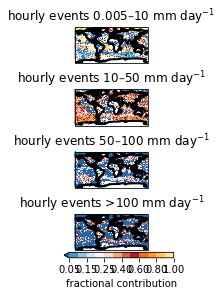

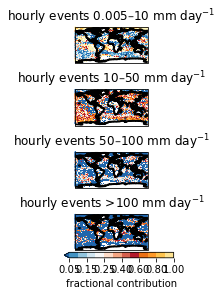

In [13]:
asop_fractional_contrib(imerg, 'hourly')

/tmp/ipykernel_6303/3955740549.py:18: RuntimeWarning: invalid value encountered in true_divide
  pdata = (da * (dig_data == i)).sum(dim='time').values / da.sum(dim='time').values
/tmp/ipykernel_6303/3955740549.py:18: RuntimeWarning: invalid value encountered in true_divide
  pdata = (da * (dig_data == i)).sum(dim='time').values / da.sum(dim='time').values
/tmp/ipykernel_6303/3955740549.py:18: RuntimeWarning: invalid value encountered in true_divide
  pdata = (da * (dig_data == i)).sum(dim='time').values / da.sum(dim='time').values
/tmp/ipykernel_6303/3955740549.py:18: RuntimeWarning: invalid value encountered in true_divide
  pdata = (da * (dig_data == i)).sum(dim='time').values / da.sum(dim='time').values


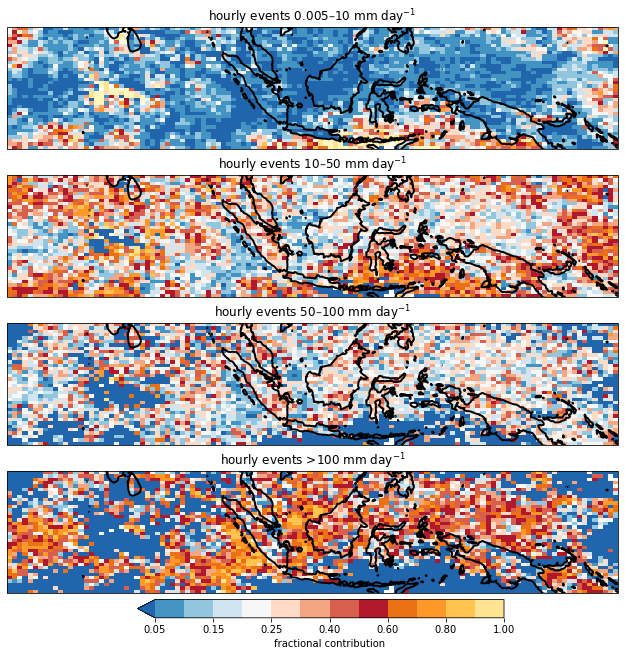

In [14]:
fig = asop_fractional_contrib(imerg.sel(longitude=slice(60, 160), latitude=slice(-10, 10)), 'hourly')
fig.set_size_inches(10, 9)

/tmp/ipykernel_6303/3955740549.py:18: RuntimeWarning: invalid value encountered in true_divide
  pdata = (da * (dig_data == i)).sum(dim='time').values / da.sum(dim='time').values
/tmp/ipykernel_6303/3955740549.py:18: RuntimeWarning: invalid value encountered in true_divide
  pdata = (da * (dig_data == i)).sum(dim='time').values / da.sum(dim='time').values
/tmp/ipykernel_6303/3955740549.py:18: RuntimeWarning: invalid value encountered in true_divide
  pdata = (da * (dig_data == i)).sum(dim='time').values / da.sum(dim='time').values
/tmp/ipykernel_6303/3955740549.py:18: RuntimeWarning: invalid value encountered in true_divide
  pdata = (da * (dig_data == i)).sum(dim='time').values / da.sum(dim='time').values


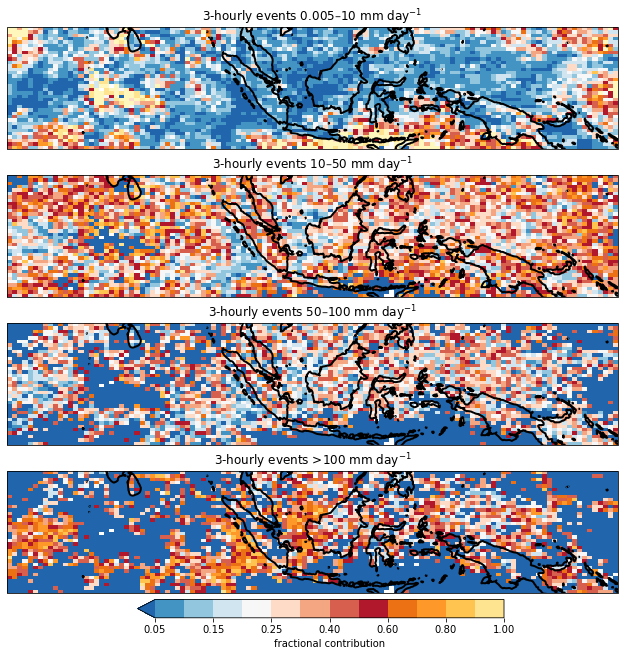

In [15]:
fig = asop_fractional_contrib(imerg.coarsen(time=3).mean().sel(longitude=slice(60, 160), latitude=slice(-10, 10)), '3-hourly')
fig.set_size_inches(10, 9)

In [16]:
def asop_7x7_spat_corr(da, biperiodic='neither'):
    if biperiodic == 'neither':
        xyslice = (None, slice(3, -3), slice(3, -3))
    elif biperiodic == 'x':
        xyslice = (None, slice(3, -3), None)
    elif biperiodic == 'y':
        xyslice = (None, None, slice(3, -3))
    elif biperiodic == 'both':
        xyslice = (None, slice(3, -3), slice(3, -3))
        
    values = da.values
    values[np.isnan(values)] = 0
    values_flat = values[xyslice].flatten()
    spat_corr = np.zeros((7, 7))
    for i, j in product(range(7), range(7)):
        print(i, j)
        shift_lon = i - 3
        shift_lat = j - 3
        spat_corr[j, i] = scipy.stats.pearsonr(values_flat, np.roll(np.roll(values, shift_lon, axis=-1), shift_lat, axis=-2)[xyslice].flatten())[0]
    clear_output()
    return spat_corr

In [17]:
spat_corr = asop_7x7_spat_corr(imerg, biperiodic='x')

In [18]:
def plot_asop_spat_corr(spat_corr):
    html_colours = ['#e8e4e7', '#fecd61', '#d5c24e', '#9ec039', '#55b545', '#399e69', '#398b79', '#37767c', '#2a6089', '#2b449d', '#361f71']
    under_colour = '#e8e4e7'
    over_colour = '#361f71'
    
    cmap = mcolors.ListedColormap(html_colours[1:-1])
    cmap.set_under(under_colour)
    cmap.set_over(over_colour)
    norm = mcolors.BoundaryNorm([0.05, 0.15, 0.25, 0.35, 0.45, 0.55, 0.65, 0.75, 0.85, 0.95], cmap.N)
    
    
    df = pd.DataFrame(spat_corr, columns=[f'{v}' for v in range(-3, 4)])[::-1]
    df.index = range(3, -4, -1)
    sns.heatmap(df, annot=True, norm=norm, cmap=cmap)

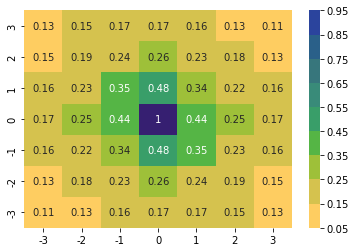

In [19]:
plot_asop_spat_corr(spat_corr)

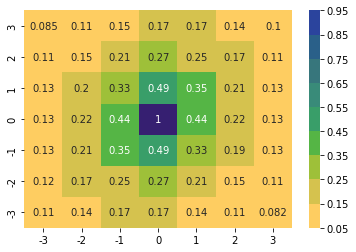

In [20]:
plot_asop_spat_corr(asop_7x7_spat_corr(imerg.coarsen(time=3).mean().sel(longitude=slice(60, 160), latitude=slice(-10, 10))))

In [21]:
360 / (216 * 2)

0.8333333333333334

In [23]:
def asop_space_time(da, biperiodic='neither'):
    spat_temp_corr = np.zeros((5, 7, 7))
    for i, j, k in product(range(7), range(7), range(5)):
        print(i, j, k)
        shift_lon = i - 3
        shift_lat = j - 3
        shift_time = k
        if k == 0:
            if biperiodic == 'neither':
                xyslice1 = (None, slice(3, -3), slice(3, -3))
            elif biperiodic == 'x':
                xyslice1 = (None, slice(3, -3), None)
            elif biperiodic == 'y':
                xyslice1 = (None, None, slice(3, -3))
            elif biperiodic == 'both':
                xyslice1 = (None, slice(3, -3), slice(3, -3))
            xyslice2 = xyslice1
        else:
            if biperiodic == 'neither':
                xyslice1 = (slice(k, None), slice(3, -3), slice(3, -3))
                xyslice2 = (slice(None, -k), slice(3, -3), slice(3, -3))
            elif biperiodic == 'x':
                xyslice1 = (slice(k, None), slice(3, -3), None)
                xyslice2 = (slice(None, -k), slice(3, -3), None)
            elif biperiodic == 'y':
                xyslice1 = (slice(k, None), None, slice(3, -3))
                xyslice2 = (slice(None, -k), None, slice(3, -3))
            elif biperiodic == 'both':
                xyslice1 = (slice(k, None), slice(3, -3), slice(3, -3))
                xyslice2 = (slice(None, -k), slice(3, -3), slice(3, -3))

        spat_temp_corr[k, j, i] = scipy.stats.pearsonr(
            da.values[xyslice1].flatten(), 
            np.roll(np.roll(da.values, shift_lon, axis=-1), shift_lat, axis=-2)[xyslice2].flatten()
        )[0] 
    clear_output()
    return spat_temp_corr


In [24]:
spat_temp_corr = asop_space_time(imerg.sel(longitude=slice(60, 160), latitude=slice(-10, 10)))

In [25]:
def plot_asop_space_time_corr(spat_temp_corr):
    html_colours = ['#e8e4e7', '#fecd61', '#d5c24e', '#9ec039', '#55b545', '#399e69', '#398b79', '#37767c', '#2a6089', '#2b449d', '#361f71']
    under_colour = '#e8e4e7'
    over_colour = '#361f71'
    
    cmap = mcolors.ListedColormap(html_colours[1:-1])
    cmap.set_under(under_colour)
    cmap.set_over(over_colour)
    norm = mcolors.BoundaryNorm([0.05, 0.15, 0.25, 0.35, 0.45, 0.55, 0.65, 0.75, 0.85, 0.95], cmap.N)
    
    x = np.linspace(-3, 3, 7)
    y = np.linspace(-3, 3, 7)
    X, Y = np.meshgrid(x, y)
    bins = np.array([0, 0.5, 1.5, 2.5, 3.5])
    d = np.digitize(np.sqrt(X**2 + Y**2), bins)

    spat_temp_corr2 = np.zeros((5, 4))
    for i in range(5):
        for j in range(1, 5):
            spat_temp_corr2[i, j - 1] = spat_temp_corr[i, :, :][d == j].mean()
    sns.heatmap(pd.DataFrame(spat_temp_corr2)[::-1], annot=True, norm=norm, cmap=cmap)

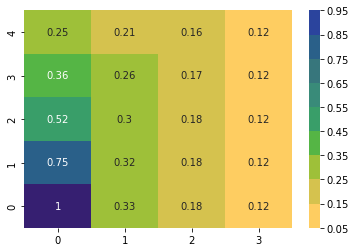

In [26]:
plot_asop_space_time_corr(spat_temp_corr)

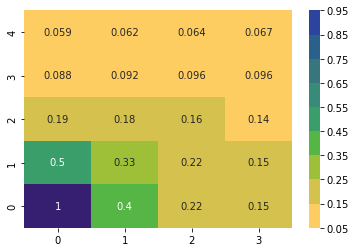

In [27]:
plot_asop_space_time_corr(asop_space_time(imerg.sel(longitude=slice(60, 160), latitude=slice(-10, 10)).coarsen(time=3).mean()))

In [28]:
from remake2 import load_remake

In [29]:
cd ../../../stoch_trig_remakefiles/

/home/users/mmuetz/projects/mcs_prime/ctrl/stoch_trig_remakefiles


In [30]:
rmk = load_remake('N216_sims_process.py')

2024-09-09 20:11:31.697 | DEBUG    | remake2.remake_base:load_rules:56 - Loading rules
2024-09-09 20:11:31.717 | DEBUG    | remake2.remake_base:load_rules:78 - inserting rules
2024-09-09 20:11:31.965 | DEBUG    | remake2.remake_base:finalize:170 - getting task status
2024-09-09 20:11:31.982 | DEBUG    | remake2.remake_base:load_rules:91 - Loaded rules


In [32]:
task = rmk.RegridImergToN216.tasks[0]
imerg = xr.open_mfdataset([v for k, v in task.inputs.items() if k.startswith('imerg')]).precipitation

In [35]:
imerg.shape

(240, 3600, 1800)

In [36]:
imerg_wp_3h = imerg.sel(lon=slice(60, 160), lat=slice(-10, 10)).coarsen(time=3).mean().load()

In [38]:
imerg_wp_3h = imerg_wp_3h.transpose('time', 'lat', 'lon')

In [39]:
imerg_wp_3h

<xarray.DataArray 'precipitation' (time: 80, lat: 200, lon: 1000)>
array([[[7.73333311e-01, 9.30000007e-01, 7.76666641e-01, ...,
         1.46999991e+00, 3.10333323e+00, 3.60000014e+00],
        [6.80000007e-01, 7.26666629e-01, 7.13333309e-01, ...,
         4.66666669e-01, 3.09999973e-01, 1.64333332e+00],
        [7.06666648e-01, 5.96666634e-01, 6.70000017e-01, ...,
         1.36666670e-01, 3.86666656e-01, 1.30333328e+00],
        ...,
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

       [[3.86666656e-01, 5.23333311e-01, 6.39999986e-01, ...,
         5.13333321e-01, 1.05333328e+00, 2.66666675e+00],
        [5.99999964e-01, 7.89999962e-01, 6.93333328e-01, ...,
         5.19999981e-01, 3.49999994e-01, 4.89999980e-01],
        [7.23333359e-01, 1.31666672e+00, 1.12000000e+00, ...,
         1.49999991e-01, 2.16666654e-01, 6.36666656e-01],
...
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

       [[3.33333318e-03, 1.33333327e-02, 1.66666657e-02, ...,
         6.66666636e-03, 3.99999991e-02, 1.13333337e-01],
        [6.66666636e-03, 1.33333327e-02, 1.33333327e-02, ...,
         5.33333309e-02, 1.59999996e-01, 1.23333335e-01],
        [1.33333327e-02, 1.33333327e-02, 1.99999996e-02, ...,
         6.66666636e-03, 3.03333312e-01, 3.26666653e-01],
        ...,
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00]]], dtype=float32)
Coordinates:
  * lat      (lat) float32 -9.95 -9.85 -9.75 -9.65 -9.55 ... 9.65 9.75 9.85 9.95
  * lon      (lon) float32 60.05 60.15 60.25 60.35 ... 159.6 159.8 159.8 159.9
  * time     (time) object 2020-07-01 05:00:00 ... 2020-07-11 02:00:00
Attributes:
    DimensionNames:    time,lon,lat
    Units:             mm/hr
    units:             mm/hr
    CodeMissingValue:  -9999.9
    LongName:          \nComplete merged microwave-infrared (gauge-adjusted)\...
    origname:          precipitation
    fullnamepath:      /Grid/precipitation
    coordinates:       Grid_time Grid_lon Grid_lat

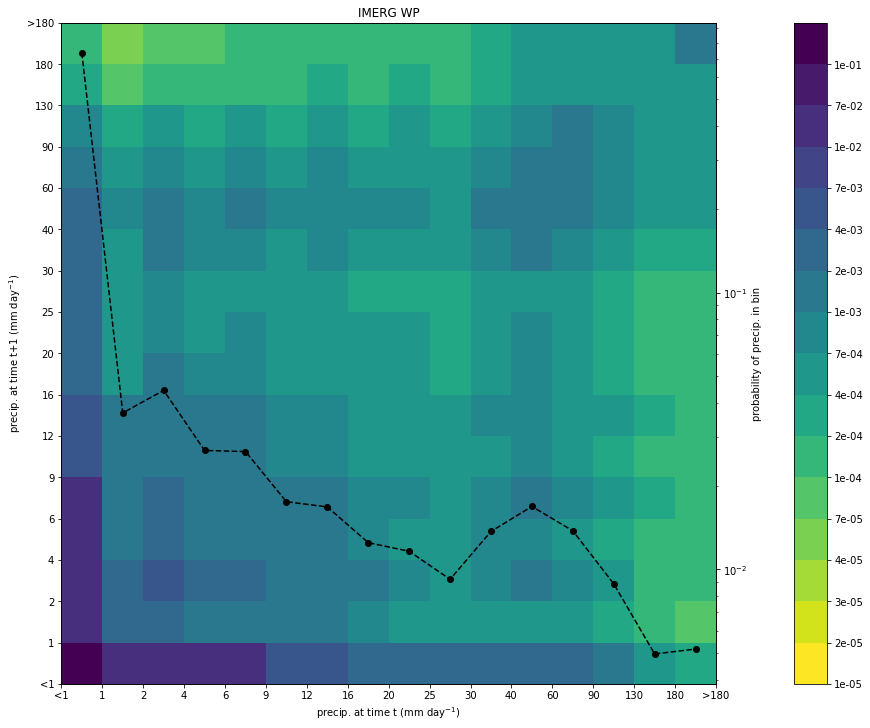

In [41]:
asop_precip_prob_matrix(imerg_wp_3h.values)
plt.title('IMERG WP');

/tmp/ipykernel_6303/2039905463.py:18: RuntimeWarning: invalid value encountered in true_divide
  pdata = (da * (dig_data == i)).sum(dim='time').values / da.sum(dim='time').values
/tmp/ipykernel_6303/2039905463.py:18: RuntimeWarning: invalid value encountered in true_divide
  pdata = (da * (dig_data == i)).sum(dim='time').values / da.sum(dim='time').values
/tmp/ipykernel_6303/2039905463.py:18: RuntimeWarning: invalid value encountered in true_divide
  pdata = (da * (dig_data == i)).sum(dim='time').values / da.sum(dim='time').values
/tmp/ipykernel_6303/2039905463.py:18: RuntimeWarning: invalid value encountered in true_divide
  pdata = (da * (dig_data == i)).sum(dim='time').values / da.sum(dim='time').values


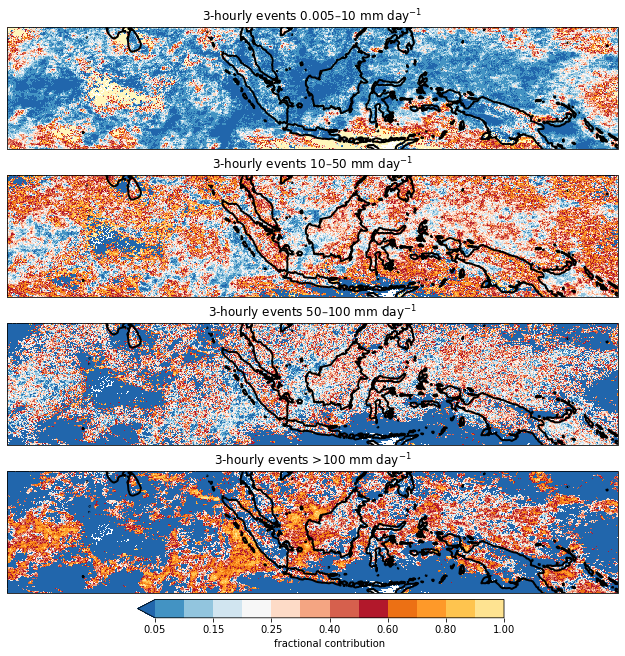

In [44]:
fig = asop_fractional_contrib(imerg_wp_3h, '3-hourly')
fig.set_size_inches(10, 9)

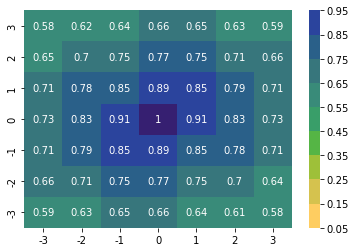

In [45]:
plot_asop_spat_corr(asop_7x7_spat_corr(imerg_wp_3h))

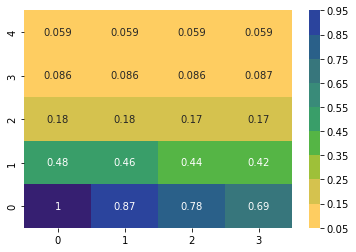

In [46]:
plot_asop_space_time_corr(asop_space_time(imerg_wp_3h))

In [49]:
np.cos(20 * np.pi / 180)

0.9396926207859084